# Logistic Regression for Classification

## What Is Logistic Regression?

Despite the name, logistic regression is a **classification** algorithm, not a regression one. It is used to predict which **category** an input belongs to, and it outputs a **probability** rather than a continuous value.

Common examples:

- Spam vs. Not Spam
- Pass vs. Fail
- Disease vs. No Disease
- Any binary 0 vs. 1 problem

## Why Not Just Use Linear Regression?

In linear regression, we predict:

$$y = \mathbf{w}^T \mathbf{x} + b$$

Where $\mathbf{x}$ is the feature vector, $\mathbf{w}$ is the weight vector, and $b$ is the bias.

The problem is that linear regression produces outputs ranging from $-\infty$ to $+\infty$. For classification, we need the output to represent a **probability** — a number between 0 and 1. A raw linear output cannot represent probability directly.

We need a function that squashes any real number into the interval $(0, 1)$. That function is the **Sigmoid**.

## The Sigmoid Function

The sigmoid function is defined as:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where:

- $z$ is any real number (the linear combination $\mathbf{w}^T\mathbf{x} + b$)
- $e$ is Euler's number ($\approx 2.718$)
- $\sigma$ (sigma) denotes the sigmoid function

The sigmoid has a characteristic **S-shaped curve**. Its key properties are:

| Input $z$ | Output $\sigma(z)$ |
|---|---|
| $z \to +\infty$ | $\sigma(z) \to 1$ |
| $z = 0$ | $\sigma(z) = 0.5$ |
| $z \to -\infty$ | $\sigma(z) \to 0$ |

It is smooth and differentiable everywhere, which is important for gradient-based optimization.

## The Logistic Regression Model

Logistic regression works in two steps. First, compute the linear combination:

$$z = \mathbf{w}^T\mathbf{x} + b$$

Then pass $z$ through the sigmoid to get a probability:

$$P(y = 1 \mid \mathbf{x}) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}}$$

This gives the **probability that the input belongs to class 1**. The closer the output is to 1, the more confident the model is that the example is a positive case.

## The Decision Boundary

To make a hard classification decision, we apply a threshold:

$$\hat{y} = \begin{cases} 1 & \text{if } P(y=1 \mid \mathbf{x}) \geq 0.5 \\ 0 & \text{if } P(y=1 \mid \mathbf{x}) < 0.5 \end{cases}$$

Since $\sigma(0) = 0.5$, the threshold of $0.5$ corresponds exactly to $z = 0$. This means the decision boundary is defined by:

$$\mathbf{w}^T\mathbf{x} + b = 0$$

This is a **linear equation** — a line in 2D, a plane in 3D, and a hyperplane in higher dimensions. This is why logistic regression produces a **linear decision boundary**. It can only separate classes that are linearly separable in the feature space.

## The Loss Function: Binary Cross-Entropy

We cannot use Mean Squared Error (MSE) for logistic regression. MSE combined with the sigmoid produces a **non-convex** loss surface with many local minima, making optimization unreliable.

Instead, we use **Binary Cross-Entropy** (also called Log Loss):

$$\mathcal{L} = -\left[ y \log(p) + (1 - y)\log(1 - p) \right]$$

Where $y$ is the true label (0 or 1) and $p$ is the predicted probability.

To understand why this works, consider the two cases:

**When the true label is $y = 1$:**

$$\mathcal{L} = -\log(p)$$

If the model predicts $p \approx 1$ (correct and confident), the loss is near zero. If the model predicts $p \approx 0$ (wrong and confident), the loss goes to $+\infty$.

**When the true label is $y = 0$:**

$$\mathcal{L} = -\log(1 - p)$$

If the model predicts $p \approx 0$ (correct), the loss is near zero. If the model predicts $p \approx 1$ (wrong), the loss goes to $+\infty$.

This asymmetry is the key property — the loss **heavily penalizes confident wrong predictions**. Combined with the sigmoid, this loss is convex, guaranteeing that gradient descent finds the global minimum.

Over all $m$ training examples, the total cost function is:

$$J(\mathbf{w}, b) = -\frac{1}{m}\sum_{i=1}^{m}\left[ y^{(i)}\log(p^{(i)}) + (1 - y^{(i)})\log(1 - p^{(i)}) \right]$$

## When To Use Logistic Regression

**Use logistic regression when:**

- The problem is binary classification (two classes)
- The decision boundary is expected to be roughly linear
- You need probability estimates, not just class labels
- The dataset is not extremely complex and interpretability matters

**Avoid logistic regression when:**

- The true decision boundary is highly nonlinear
- The data has complex multi-modal distributions
- Classes overlap heavily in the feature space

For nonlinear boundaries, consider kernelized methods, decision trees, or neural networks. For multi-class problems, logistic regression can be extended using the **softmax function**, which generalizes the sigmoid to more than two classes.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score

np.random.seed(42)

# Create Class 0 data
X0 = np.random.randn(100, 2)  + np.array([-2, -2])
# randn -> generates Gaussian distributed points
# + [-2,-2] shifts cluster to bottom-left
print(X0)
# Create Class 1 data
X1 = np.random.randn(100, 2) + np.array([2, 2])
# shift cluster to top-right

# Combine both classes vertically (stack rows)
X = np.vstack((X0, X1))

# Create labels
y = np.hstack((np.zeros(100), np.ones(100)))
# First 100 = class 0
# Next 100 = class 1

[[-1.50328585 -2.1382643 ]
 [-1.35231146 -0.47697014]
 [-2.23415337 -2.23413696]
 [-0.42078718 -1.23256527]
 [-2.46947439 -1.45743996]
 [-2.46341769 -2.46572975]
 [-1.75803773 -3.91328024]
 [-3.72491783 -2.56228753]
 [-3.01283112 -1.68575267]
 [-2.90802408 -3.4123037 ]
 [-0.53435123 -2.2257763 ]
 [-1.9324718  -3.42474819]
 [-2.54438272 -1.88907741]
 [-3.15099358 -1.62430198]
 [-2.60063869 -2.29169375]
 [-2.60170661 -0.14772182]
 [-2.01349722 -3.05771093]
 [-1.17745509 -3.22084365]
 [-1.7911364  -3.95967012]
 [-3.32818605 -1.80313876]
 [-1.26153342 -1.82863172]
 [-2.11564828 -2.3011037 ]
 [-3.47852199 -2.71984421]
 [-2.46063877 -0.94287777]
 [-1.65638171 -3.76304016]
 [-1.67591603 -2.38508228]
 [-2.676922   -1.38832371]
 [-0.96900048 -1.06871988]
 [-2.83921752 -2.30921238]
 [-1.66873657 -1.02445487]
 [-2.47917424 -2.18565898]
 [-3.10633497 -3.19620662]
 [-1.18747418 -0.64375997]
 [-2.07201012 -0.9964671 ]
 [-1.63836397 -2.64511975]
 [-1.63860439 -0.46196343]
 [-2.03582604 -0.43535634]
 

In [19]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42    
)

model = LogisticRegression()

model.fit(X_train, y_train)
# This performs:
# 1. Computes z = w^T x + b
# 2. Applies sigmoid
# 3. Minimizes log loss using optimization

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]
# Gives probability of class 1

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 1.0
Confusion Matrix:
 [[21  0]
 [ 0 19]]
R2 score: 1.0


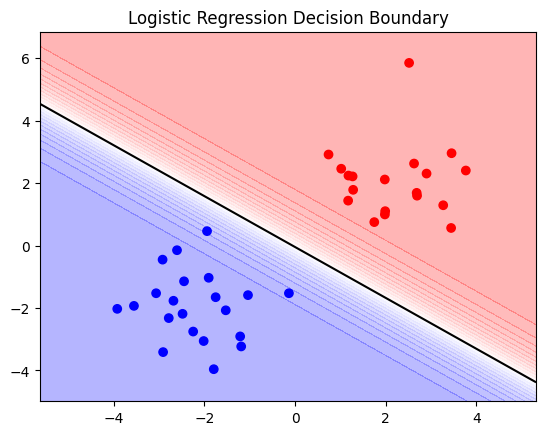

In [22]:
# Create grid for plotting
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Flatten grid to feed into model
grid = np.c_[xx.ravel(), yy.ravel()]

# Get probability predictions
probs = model.predict_proba(grid)[:, 1]
probs = probs.reshape(xx.shape)

# Plot probability surface
plt.contourf(xx, yy, probs, levels=25, cmap="bwr", alpha=0.3)

# Plot test points only (to visualize generalization)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="bwr")

# Draw decision boundary at probability = 0.5
plt.contour(xx, yy, probs, levels=[0.5], colors='black')

plt.title("Logistic Regression Decision Boundary")
plt.show()